# Classic ML Feature Engineering
In this notebook we compare Bag-of-Words and TF-IDF features and inspect how n-grams affect sentiment classification.

**1. Setup and data splits**  
Load cleaned data from the preprocessing artifact and create reproducible train/validation/test splits.

Why this step matters:
- Reproducible splits (fixed random state) make experiments comparable over time.
- A dedicated validation set supports tuning decisions without touching the test set.
- This protects against optimistic bias and keeps final test evaluation honest.

What we are trying to learn:
- Whether the data pipeline is stable and ready for fair model comparisons.

In [27]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import FIGURES_DIR, RESULTS_DIR
from src.data_loader import get_splits
from src.features import get_bow_features, get_tfidf_features

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
metrics_dir = RESULTS_DIR / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)

X_train_text, y_train, X_val_text, y_val, X_test_text, y_test = get_splits(verbose=True)
print('Train size:', X_train_text.shape[0])
print('Val size  :', X_val_text.shape[0])
print('Test size :', X_test_text.shape[0])

Loaded 50,000 rows from preprocessed IMDB dataset.
Split sizes:
  train: 34,999 (70%)
  val  :  7,501 (15%)
  test :  7,500 (15%)
Label distribution (positive class count):
  train: 17,500 / 34,999
  val  :  3,750 / 7,501
  test :  3,750 / 7,500
Train size: 34999
Val size  : 7501
Test size : 7500


**2. BoW vs TF-IDF baseline**  
Use Logistic Regression with the same model settings to compare raw counts vs TF-IDF weighting.  

How to interpret this result:
- If TF-IDF outperforms BoW, frequent but uninformative words are likely being down-weighted effectively.
- If gains are small, preprocessing and model choice may matter more than weighting scheme.
- The stronger baseline becomes the default representation for later classic-model experiments.

What we are trying to learn:
- Which weighting scheme gives a stronger and more stable starting baseline.

In [28]:
bow = get_bow_features(X_train_text, X_val_text, X_test_text, max_features=10_000, ngram_range=(1, 1))
tfidf = get_tfidf_features(X_train_text, X_val_text, X_test_text, max_features=10_000, ngram_range=(1, 1))

lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(bow['train'], y_train)
bow_val_pred = lr_bow.predict(bow['val'])

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(tfidf['train'], y_train)
tfidf_val_pred = lr_tfidf.predict(tfidf['val'])

baseline_results = [
    {
        'representation': 'BoW (unigram)',
        'val_accuracy': accuracy_score(y_val, bow_val_pred),
        'val_f1': f1_score(y_val, bow_val_pred),
    },
    {
        'representation': 'TF-IDF (unigram)',
        'val_accuracy': accuracy_score(y_val, tfidf_val_pred),
        'val_f1': f1_score(y_val, tfidf_val_pred),
    },
]

baseline_df = pd.DataFrame(baseline_results)
baseline_df

,representation,val_accuracy,val_f1
0,BoW (unigram),0.869484,0.869727
1,TF-IDF (unigram),0.885749,0.886865


**3. Unigram vs bigram (TF-IDF)**  
Evaluate whether adding bigrams improves validation performance by capturing phrase-level cues such as negation.  

How to interpret this result:
- Improvement from ngram_1-2 suggests phrase context adds useful signal.
- No improvement suggests extra dimensionality may add noise or overfitting risk.
- This step informs the default n-gram setting for the rest of the modeling pipeline.

What we are trying to learn:
- Whether phrase-level context contributes meaningful predictive signal in this dataset.

In [29]:
ngram_results = []

for ngram_range in [(1, 1), (1, 2)]:
    features = get_tfidf_features(
        X_train_text,
        X_val_text,
        X_test_text,
        max_features=10_000,
        ngram_range=ngram_range,
    )

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(features['train'], y_train)
    val_pred = model.predict(features['val'])

    ngram_results.append(
        {
            'representation': f"ngram_{ngram_range[0]}-{ngram_range[1]}",
            'val_accuracy': accuracy_score(y_val, val_pred),
            'val_f1': f1_score(y_val, val_pred),
        }
    )

ngram_df = pd.DataFrame(ngram_results)
ngram_df

,representation,val_accuracy,val_f1
0,ngram_1-1,0.885749,0.886865
1,ngram_1-2,0.887482,0.888625


**4. Top TF-IDF features (unigram + bigram)**  
Inspect strongest positive and negative coefficients from Logistic Regression to explain model behavior.  

How to interpret this result:
- Positive weights increase probability of the positive class; negative weights do the opposite.
- Use this as interpretability evidence in the report, not as causal proof.
- If top terms look noisy or domain-irrelevant, revisit preprocessing thresholds (min_df/max_df, n-grams).

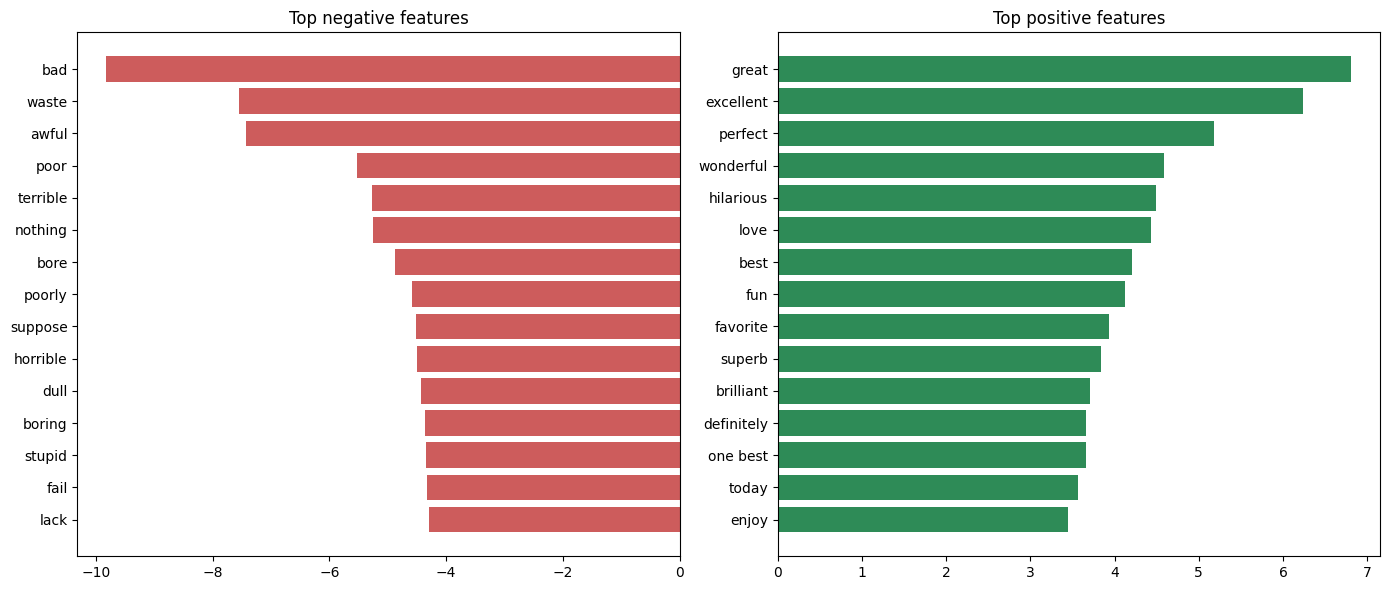

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\tfidf_top_features.png


(     feature    weight
 0      great  6.812306
 1  excellent  6.234347
 2    perfect  5.178528
 3  wonderful  4.592038
 4  hilarious  4.495631
 5       love  4.430967
 6       best  4.202182
 7        fun  4.122265
 8   favorite  3.933864
 9     superb  3.836182,
     feature    weight
 0       bad -9.828345
 1     waste -7.549051
 2     awful -7.435086
 3      poor -5.535449
 4  terrible -5.271656
 5   nothing -5.251451
 6      bore -4.870029
 7    poorly -4.587599
 8   suppose -4.516678
 9  horrible -4.498716)

In [30]:
tfidf_bigram = get_tfidf_features(
    X_train_text,
    X_val_text,
    X_test_text,
    max_features=10_000,
    ngram_range=(1, 2),
)

lr_bigram = LogisticRegression(max_iter=1000, random_state=42)
lr_bigram.fit(tfidf_bigram['train'], y_train)

feature_names = tfidf_bigram['vectorizer'].get_feature_names_out()
coefs = lr_bigram.coef_[0]

top_n = 15
top_positive_idx = coefs.argsort()[-top_n:][::-1]
top_negative_idx = coefs.argsort()[:top_n]

top_positive = pd.DataFrame({
    'feature': feature_names[top_positive_idx],
    'weight': coefs[top_positive_idx],
})
top_negative = pd.DataFrame({
    'feature': feature_names[top_negative_idx],
    'weight': coefs[top_negative_idx],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_negative['feature'], top_negative['weight'], color='indianred')
axes[0].set_title('Top negative features')
axes[0].invert_yaxis()

axes[1].barh(top_positive['feature'], top_positive['weight'], color='seagreen')
axes[1].set_title('Top positive features')
axes[1].invert_yaxis()

plt.tight_layout()
feature_plot_path = FIGURES_DIR / 'tfidf_top_features.png'
plt.savefig(feature_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved -> {feature_plot_path}')
top_positive.head(10), top_negative.head(10)

**5. Save metrics for report reuse**  
Persist feature-engineering metrics to a CSV so later notebooks and report sections use one consistent source of truth.

Why this helps:
- Avoids manual copy/paste errors.
- Keeps outputs reproducible.
- Makes final comparison tables easier to build and audit.

What we are trying to learn:
- Whether feature-engineering decisions are documented in a reusable, machine-readable format.

In [31]:
metrics_df = pd.concat(
    [
        baseline_df.assign(experiment='bow_vs_tfidf'),
        ngram_df.assign(experiment='tfidf_ngram_comparison'),
    ],
    ignore_index=True,
)

metrics_path = metrics_dir / 'feature_engineering_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved -> {metrics_path}')
metrics_df

Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\feature_engineering_metrics.csv


,representation,val_accuracy,val_f1,experiment
0,BoW (unigram),0.869484,0.869727,bow_vs_tfidf
1,TF-IDF (unigram),0.885749,0.886865,bow_vs_tfidf
2,ngram_1-1,0.885749,0.886865,tfidf_ngram_comparison
3,ngram_1-2,0.887482,0.888625,tfidf_ngram_comparison


**6. Classic model suite and evaluation**

This section applies a consistent classic-model suite on the same TF-IDF feature space:
- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM
- Random Forest
- GridSearchCV tuning for Logistic Regression

Why this step matters:
- A shared feature representation makes model comparison fair.
- Multiple model families let us compare linear, probabilistic, and ensemble behavior.
- Validation-first evaluation helps us select robust candidates before final test comparison.

What we are trying to learn:
- Which model family gives the strongest validation performance under identical feature settings.
- Whether focused tuning improves the selected baseline.

Literature alignment notes:
- Chapter 5 supports supervised classification workflows and evaluation via confusion matrix, precision, recall, and F1.
- Chapter 6 motivates ensemble learning (Random Forest) and grid-search style tuning.
- Chapter 4 frames feature importance as model-specific evidence, not causal proof.

In [32]:
from joblib import dump
import importlib

import src.classic_models as classic_models_module
import src.evaluation as evaluation_module

classic_models_module = importlib.reload(classic_models_module)
evaluation_module = importlib.reload(evaluation_module)

hyperparameter_tuning = classic_models_module.hyperparameter_tuning
train_logistic_regression = classic_models_module.train_logistic_regression
train_naive_bayes = classic_models_module.train_naive_bayes
train_random_forest = classic_models_module.train_random_forest
train_svm = classic_models_module.train_svm

build_model_comparison_table = evaluation_module.build_model_comparison_table
plot_confusion_matrices_grid = evaluation_module.plot_confusion_matrices_grid
save_metrics_table = evaluation_module.save_metrics_table
save_models = evaluation_module.save_models

models_dir = project_root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

**7. Build a shared TF-IDF feature matrix**

What we are doing:
- Create one TF-IDF representation (unigram + bigram) used by all classic models.

Purpose:
- Keep feature engineering constant so model differences are attributable to the algorithm, not the input format.

What we are trying to learn:
- Whether this representation is stable and expressive enough for fair multi-model comparison.

In [33]:
classic_features = get_tfidf_features(
    X_train_text,
    X_val_text,
    X_test_text,
    max_features=10_000,
    ngram_range=(1, 2),
)

X_train_classic = classic_features['train']
X_val_classic = classic_features['val']
feature_names_classic = classic_features['vectorizer'].get_feature_names_out()

print('Classic TF-IDF train shape:', X_train_classic.shape)
print('Classic TF-IDF val shape  :', X_val_classic.shape)

Classic TF-IDF train shape: (34999, 10000)
Classic TF-IDF val shape  : (7501, 10000)


**8. Train the classic model set on the same features**

What we are doing:
- Fit Logistic Regression, Naive Bayes, Linear SVM, and Random Forest on identical training data.

Purpose:
- Compare model families under controlled conditions.

What we are trying to learn:
- Which model class provides the best validation tradeoff between accuracy, precision, recall, and F1.

In [34]:
model_runs = {
    'Logistic Regression': train_logistic_regression(X_train_classic, y_train, X_val_classic, y_val),
    'Naive Bayes': train_naive_bayes(X_train_classic, y_train, X_val_classic, y_val),
    'Linear SVM': train_svm(X_train_classic, y_train, X_val_classic, y_val),
    'Random Forest': train_random_forest(X_train_classic, y_train, X_val_classic, y_val),
}

model_predictions = {}
trained_models = {}

for model_name, (model, y_pred, report_text) in model_runs.items():
    trained_models[model_name] = model
    model_predictions[model_name] = y_pred
    print(f"\n{'=' * 70}")
    print(model_name)
    print(report_text)


Logistic Regression
              precision    recall  f1-score   support

           0     0.8957    0.8771    0.8863      3751
           1     0.8796    0.8979    0.8886      3750

    accuracy                         0.8875      7501
   macro avg     0.8876    0.8875    0.8875      7501
weighted avg     0.8876    0.8875    0.8875      7501


Naive Bayes
              precision    recall  f1-score   support

           0     0.8702    0.8456    0.8578      3751
           1     0.8498    0.8739    0.8617      3750

    accuracy                         0.8598      7501
   macro avg     0.8600    0.8598    0.8597      7501
weighted avg     0.8600    0.8598    0.8597      7501


Linear SVM
              precision    recall  f1-score   support

           0     0.8879    0.8824    0.8851      3751
           1     0.8831    0.8885    0.8858      3750

    accuracy                         0.8855      7501
   macro avg     0.8855    0.8855    0.8855      7501
weighted avg     0.8855    0

**9. Aggregate validation metrics into a comparison table**

What we are doing:
- Build a unified metrics table from model predictions and save it for reporting reuse.

Purpose:
- Keep results reproducible and easy to compare across models.

What we are trying to learn:
- The ranking of candidate classic models on validation performance.

In [35]:
classic_comparison_df = build_model_comparison_table(y_val, model_predictions, split_name='validation')
classic_metrics_path = metrics_dir / 'classic_models_metrics.csv'
save_metrics_table(classic_comparison_df, classic_metrics_path)

print(f'Saved -> {classic_metrics_path}')
classic_comparison_df

Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\classic_models_metrics.csv


,model,split,accuracy,precision,recall,f1
0,Logistic Regression,validation,0.887482,0.879572,0.897867,0.888625
1,Linear SVM,validation,0.885482,0.883117,0.888533,0.885817
2,Naive Bayes,validation,0.859752,0.849844,0.873867,0.861688
3,Random Forest,validation,0.854953,0.853989,0.856267,0.855126


**10. Visualize confusion matrices for error analysis**

What we are doing:
- Plot confusion matrices for each model in one grid.

Purpose:
- Move beyond aggregate metrics and inspect error balance between false positives and false negatives.

What we are trying to learn:
- Which models are making similar mistakes and which model has more balanced decision behavior.

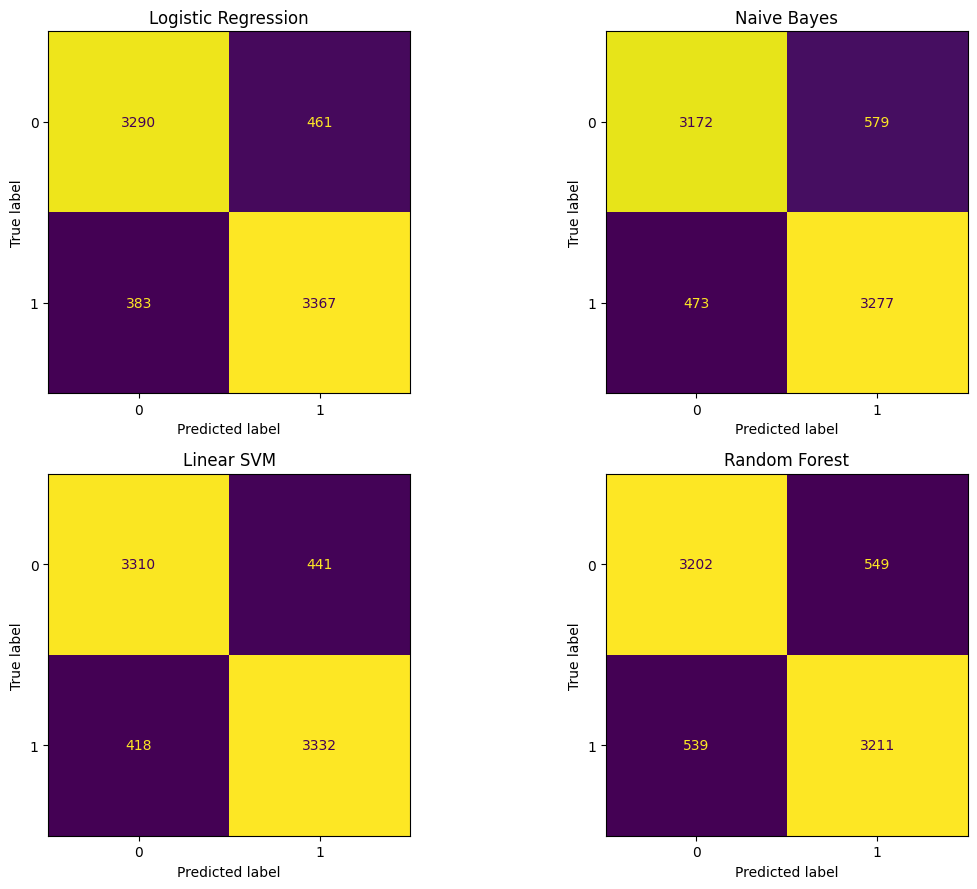

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\classic_models_confusion_matrices.png


In [36]:
cm_fig = plot_confusion_matrices_grid(y_val, model_predictions, n_cols=2, figsize=(12, 9))
cm_plot_path = FIGURES_DIR / 'classic_models_confusion_matrices.png'
cm_fig.savefig(cm_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved -> {cm_plot_path}')

**11. Tune Logistic Regression with grid search**

What we are doing:
- Run GridSearchCV on Logistic Regression and re-evaluate tuned predictions on validation.

Purpose:
- Check whether focused hyperparameter tuning adds measurable gains over defaults.

What we are trying to learn:
- If tuning meaningfully improves the strongest linear baseline and changes model ranking.

In [37]:
grid_search = hyperparameter_tuning(
    X_train_classic,
    y_train,
    param_grid={'C': [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=5,
    scoring='f1',
)

best_lr = grid_search.best_estimator_
tuned_lr_val_pred = best_lr.predict(X_val_classic)
model_predictions['Logistic Regression (Tuned)'] = tuned_lr_val_pred
trained_models['Logistic Regression (Tuned)'] = best_lr

print('Best params:', grid_search.best_params_)
print('Best CV score:', f"{grid_search.best_score_:.4f}")

classic_comparison_with_tuned_df = build_model_comparison_table(
    y_val,
    model_predictions,
    split_name='validation',
)
classic_tuned_metrics_path = metrics_dir / 'classic_models_metrics_with_tuning.csv'
save_metrics_table(classic_comparison_with_tuned_df, classic_tuned_metrics_path)
print(f'Saved -> {classic_tuned_metrics_path}')
classic_comparison_with_tuned_df

Best params: {'C': 1.0}
Best CV score: 0.8906
Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\classic_models_metrics_with_tuning.csv


,model,split,accuracy,precision,recall,f1
0,Logistic Regression,validation,0.887482,0.879572,0.897867,0.888625
1,Logistic Regression (Tuned),validation,0.887482,0.879572,0.897867,0.888625
2,Linear SVM,validation,0.885482,0.883117,0.888533,0.885817
3,Naive Bayes,validation,0.859752,0.849844,0.873867,0.861688
4,Random Forest,validation,0.854953,0.853989,0.856267,0.855126


**12. Inspect Random Forest feature importance**

What we are doing:
- Plot top Random Forest feature importances from the shared TF-IDF vocabulary.

Purpose:
- Add model-specific interpretability evidence for report and discussion.

What we are trying to learn:
- Which terms the ensemble model relies on most and whether those terms are sentiment-relevant.

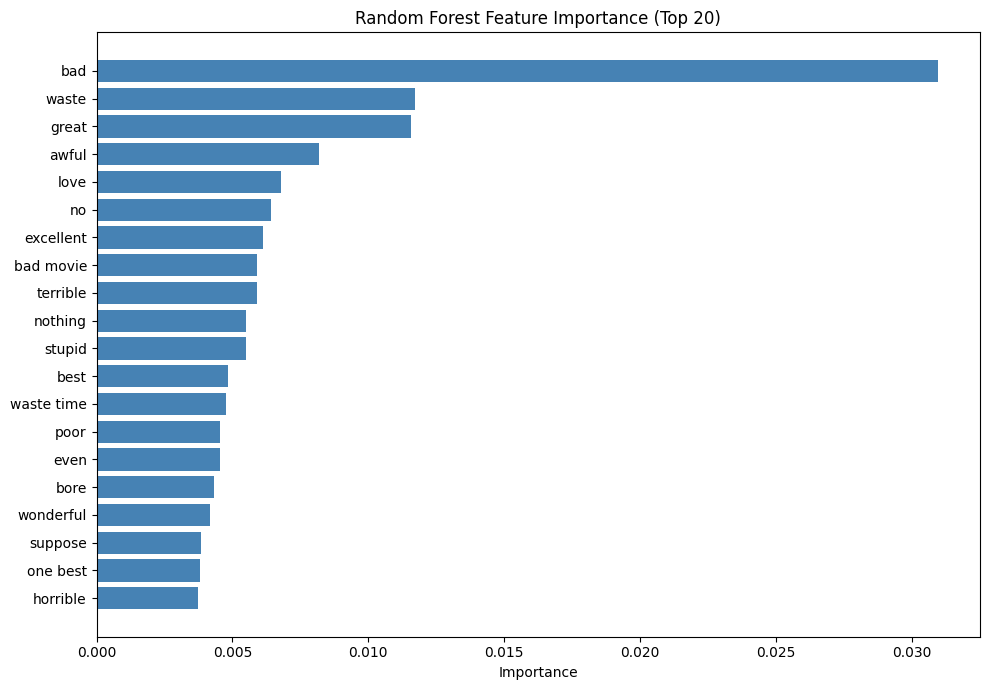

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\random_forest_feature_importance.png


In [38]:
rf_model = trained_models['Random Forest']
rf_importances = rf_model.feature_importances_

rf_top_n = 20
rf_top_idx = rf_importances.argsort()[-rf_top_n:]

rf_fig, rf_ax = plt.subplots(figsize=(10, 7))
rf_ax.barh(range(rf_top_n), rf_importances[rf_top_idx], color='steelblue')
rf_ax.set_yticks(range(rf_top_n))
rf_ax.set_yticklabels(feature_names_classic[rf_top_idx])
rf_ax.set_title('Random Forest Feature Importance (Top 20)')
rf_ax.set_xlabel('Importance')
rf_fig.tight_layout()

rf_plot_path = FIGURES_DIR / 'random_forest_feature_importance.png'
rf_fig.savefig(rf_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {rf_plot_path}')

**13. Save trained models and vectorizer artifacts**

What we are doing:
- Persist fitted models and the shared TF-IDF vectorizer to disk.

Purpose:
- Ensure experiments are reproducible and reusable by later notebooks and evaluation stages.

What we are trying to learn:
- Whether artifacts are complete and ready for downstream comparison workflows.

In [39]:
save_models(trained_models, models_dir)
vectorizer_path = models_dir / 'tfidf_vectorizer_classic_models.joblib'
dump(classic_features['vectorizer'], vectorizer_path)

expected_artifacts = [
    'logistic_regression.joblib',
    'logistic_regression_(tuned).joblib',
    'naive_bayes.joblib',
    'linear_svm.joblib',
    'random_forest.joblib',
    vectorizer_path.name,
]

print('Saved model/vectorizer artifacts:')
for name in expected_artifacts:
    print('-', name)

Saved model/vectorizer artifacts:
- logistic_regression.joblib
- logistic_regression_(tuned).joblib
- naive_bayes.joblib
- linear_svm.joblib
- random_forest.joblib
- tfidf_vectorizer_classic_models.joblib


**Classic model literature notes (report-ready summary)**

- Book connection (Ch. 5): confusion matrix and precision/recall/F1 are required to interpret classifier behavior beyond accuracy.
- Book connection (Ch. 6): Random Forest and GridSearchCV provide ensemble and tuning perspectives that complement linear baselines.
- Interpretation guardrail: tuned validation performance is used for model selection, while final test conclusions are reserved for the final comparison stage.
- Interpretation guardrail: feature-importance plots and linear coefficients show learned signal patterns, not causal effects.

What we are trying to learn:
- Which model class is most reliable for this sentiment task before deep-learning comparison.
- Which errors persist across models and may require better features or architecture changes.